# From trajectories to causal interventions

## A composed interpretability investigation of a TorchRL-compatible policy

Real interpretability investigations are not single method calls. This notebook follows one question through a complete evidence chain:

> **Where does a fitted-Q navigation policy represent that its goal lies to the left, what input evidence supports that representation, and does the representation causally affect behavior?**

The example is deliberately small, deterministic, offline, and CPU-only. Its purpose is to make the experimental structure inspectable:

1. establish competent closed-loop behavior;
2. attribute chosen action values to hidden channels;
3. select a concept-associated channel;
4. trace that channel back to the observation;
5. intervene on it;
6. measure open-loop specificity and closed-loop consequences.

The scientific conclusion is limited to this fitted-Q corridor policy. The reusable result is the workflow.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from tensordict import TensorDict
from tensordict.nn import TensorDictModule, TensorDictSequential
from torch import nn

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="torchrl")
    from torchrl.modules import QValueModule

from tdhook.attribution import LRP
from tdhook.concepts import ChannelConditionedLRP, ConceptSelection
from tdhook.latent import ActivationCaching, SteeringVectors
from tdhook.targets import Target
from tdhook.workflow import Workflow

torch.manual_seed(7)
torch.set_num_threads(1)

CORRIDOR_LENGTH = 9
FEATURES = 8
DEVICE = torch.device("cpu")

## 1. A complete, inspectable decision problem

An agent and a goal occupy a nine-cell corridor. The observation contains two one-hot planes: the agent position and the goal position. Actions are `0 = left` and `1 = right`.

We enumerate the complete non-terminal state space and both transitions from every state. This gives a frozen evaluation panel rather than a sample whose composition changes between executions.

In [2]:
def encode_state(agent_position: int, goal_position: int) -> torch.Tensor:
    observation = torch.zeros(2, CORRIDOR_LENGTH, device=DEVICE)
    observation[0, agent_position] = 1.0
    observation[1, goal_position] = 1.0
    return observation


observations = []
next_observations = [[], []]
rewards = [[], []]
dones = [[], []]
optimal_actions = []
goal_is_right = []
state_pairs = []

for agent_position in range(CORRIDOR_LENGTH):
    for goal_position in range(CORRIDOR_LENGTH):
        if agent_position == goal_position:
            continue
        observations.append(encode_state(agent_position, goal_position))
        optimal_actions.append(int(goal_position > agent_position))
        goal_is_right.append(int(goal_position > agent_position))
        state_pairs.append((agent_position, goal_position))

        for action, displacement in ((0, -1), (1, 1)):
            next_position = max(0, min(CORRIDOR_LENGTH - 1, agent_position + displacement))
            done = next_position == goal_position
            next_observations[action].append(encode_state(next_position, goal_position))
            rewards[action].append(1.0 if done else -0.02)
            dones[action].append(done)

observations = torch.stack(observations)
next_observations = torch.stack([torch.stack(values) for values in next_observations], dim=1)
rewards = torch.tensor(rewards, device=DEVICE).T
dones = torch.tensor(dones, device=DEVICE).T
optimal_actions = torch.tensor(optimal_actions, device=DEVICE)
goal_is_right = torch.tensor(goal_is_right, device=DEVICE)

evaluation_panel = TensorDict(
    {
        "observation": observations,
        "target_action": optimal_actions,
        "concept_labels": goal_is_right,
    },
    batch_size=[len(observations)],
    device=DEVICE,
)

print(f"Frozen panel: {len(observations)} non-terminal states")
print(f"Observation shape: {tuple(observations.shape)}")
print(f"Left/right concepts: {torch.bincount(goal_is_right).tolist()}")

Frozen panel: 72 non-terminal states
Observation shape: (72, 2, 9)
Left/right concepts: [36, 36]


## 2. Fit a TorchRL-compatible Q policy

The neural network maps the structured observation to two action values. A `TensorDictModule` gives the actor an explicit `observation → action_value` contract; TorchRL's `QValueModule` supplies the greedy action-selection stage.

To keep the notebook short and reproducible, fitted Q-iteration trains on the complete transition table. The interpretability workflow is applied only after training, with the actor frozen in evaluation mode.

In [3]:
class CorridorQNetwork(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.features = nn.Sequential(
            nn.Linear(2 * CORRIDOR_LENGTH, 16),
            nn.ReLU(),
            nn.Linear(16, FEATURES),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(FEATURES, 2)

    def forward(self, observation: torch.Tensor) -> torch.Tensor:
        return self.policy_head(self.features(self.flatten(observation)))


q_network = CorridorQNetwork().to(DEVICE)
target_network = CorridorQNetwork().to(DEVICE)
target_network.load_state_dict(q_network.state_dict())
optimizer = torch.optim.Adam(q_network.parameters(), lr=0.02)

loss_history = []
for iteration in range(600):
    with torch.no_grad():
        next_values = target_network(next_observations.flatten(0, 1)).max(-1).values.reshape(len(observations), 2)
        bellman_targets = rewards + 0.95 * (~dones) * next_values
    predicted_values = q_network(observations)
    loss = nn.functional.smooth_l1_loss(predicted_values, bellman_targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if iteration % 10 == 0:
        target_network.load_state_dict(q_network.state_dict())
    loss_history.append(float(loss.detach()))

q_network.eval()
actor = TensorDictModule(q_network, in_keys=["observation"], out_keys=["action_value"])
policy = TensorDictSequential(actor, QValueModule(action_space="categorical"))

with torch.no_grad():
    policy_output = policy(evaluation_panel.select("observation").clone())
    policy_accuracy = (policy_output["action"] == optimal_actions).float().mean().item()

print(f"Final Bellman loss: {loss_history[-1]:.6f}")
print(f"Greedy action accuracy on the complete panel: {policy_accuracy:.1%}")
assert policy_accuracy == 1.0

Final Bellman loss: 0.000065
Greedy action accuracy on the complete panel: 100.0%


In [4]:
def rollout(start: int, goal: int, *, intervention: Workflow | None = None, max_steps: int = 12):
    position = start
    path = [position]
    for _ in range(max_steps):
        if position == goal:
            break
        step = TensorDict(
            {"observation": encode_state(position, goal).unsqueeze(0)},
            batch_size=[1],
            device=DEVICE,
        )
        with torch.no_grad():
            if intervention is None:
                action_values = actor(step)["action_value"]
            else:
                action_values = intervention(actor, step)["action_value"]
        action = int(action_values.argmax(-1).item())
        position = max(0, min(CORRIDOR_LENGTH - 1, position + (-1 if action == 0 else 1)))
        path.append(position)
    return path, position == goal


baseline_results = [rollout(start, goal) for start, goal in state_pairs]
baseline_success = np.mean([success for _path, success in baseline_results])
print(f"Closed-loop success across all start-goal pairs: {baseline_success:.1%}")
print("Example left-goal path:", rollout(6, 1)[0])
print("Example right-goal path:", rollout(2, 7)[0])
assert baseline_success == 1.0

Closed-loop success across all start-goal pairs: 100.0%
Example left-goal path: [6, 5, 4, 3, 2, 1]
Example right-goal path: [2, 3, 4, 5, 6, 7]


## 3. Declare the diagnostic workflow

The concept label is whether the goal lies to the right. We ask for the opposite direction in `ConceptSelection`: the channel whose chosen-action relevance is most associated with **left-goal** states.

The three steps have distinct roles:

1. `LRP` attributes the chosen action value to the second hidden linear layer;
2. `ConceptSelection` contrasts those relevances between right- and left-goal states;
3. `ChannelConditionedLRP` traces only the selected hidden channel back to the observation.

The data dependency is explicit in the TensorDict. No callback-owned cache crosses the two model passes.

In [5]:
def chosen_action_value(targets: TensorDict, additional: TensorDict) -> TensorDict:
    values = targets["action_value"]
    chosen = values.gather(-1, additional["target_action"].unsqueeze(-1)).squeeze(-1)
    return TensorDict({"chosen_action_value": chosen}, batch_size=targets.batch_size)


lrp_options = {
    "init_attr_targets": chosen_action_value,
    "additional_init_keys": ["target_action"],
    "warn_on_missing_rule": False,
}

diagnosis = Workflow(
    LRP(
        input_modules=["features.2"],
        attribution_key=("attributions", "concept_examples"),
        **lrp_options,
    ),
    ConceptSelection(
        ("attributions", "concept_examples", "features.2"),
        direction="negative",
    ),
    ChannelConditionedLRP(
        LRP(**lrp_options),
        condition_module="features.2",
    ),
)

diagnostic_plan = diagnosis.plan(actor, evaluation_panel)
plan_rows = [
    {
        "steps": " + ".join(execution.steps),
        "kind": execution.kind,
        "model_passes": execution.model_passes,
        "coexecuted": execution.coexecuted,
    }
    for execution in diagnostic_plan.executions
]

print(f"Planned model passes: {diagnostic_plan.model_passes}")
for row in plan_rows:
    print(row)
assert diagnostic_plan.model_passes == 2

Planned model passes: 2
{'steps': '0:LRP', 'kind': 'method', 'model_passes': 1, 'coexecuted': False}
{'steps': '1:ConceptSelection', 'kind': 'operator', 'model_passes': 0, 'coexecuted': False}
{'steps': '2:ChannelConditionedLRP', 'kind': 'method', 'model_passes': 1, 'coexecuted': False}


In [6]:
step_descriptions = diagnosis.describe(
    actor,
    evaluation_panel,
    callback_identifiers={chosen_action_value: "tutorial.chosen-action-value/v1"},
)

for description in step_descriptions:
    print(description.to_dict())

{'method_type': 'tdhook.attribution.lrp.LRP', 'parameters': {'additional_init_keys': ('target_action',), 'attribution_key': ('attributions', 'concept_examples'), 'cache_callback': None, 'clean_intermediate_keys': True, 'init_attr_cache_in': None, 'init_attr_grads': None, 'init_attr_inputs': None, 'init_attr_targets': {'identifier': 'tutorial.chosen-action-value/v1'}, 'input_modules': ('features.2',), 'output_grad_callbacks': None, 'rule_mapper': None, 'skip_modules': None, 'target_modules': None, 'use_inputs': True, 'use_outputs': True, 'warn_on_missing_rule': False}, 'execution': {'autograd_lifetime': 'call', 'gradient_mode': 'required', 'model_passes': 1}, 'in_keys': ('observation', 'target_action'), 'out_keys': ('action_value', ('attributions', 'concept_examples', 'observation'), ('attributions', 'concept_examples', 'features.2'))}
{'method_type': 'tdhook.concepts.ChannelConditionedLRP', 'parameters': {'attribution_key': ('attributions', 'conditioned'), 'base': {'execution': {'autog

## 4. Run the representation analysis

The selection score is a contrast, not a causal effect. It ranks channels by how differently their absolute chosen-action relevance appears in right- versus left-goal states. The intervention stage below will test the resulting hypothesis separately.

In [7]:
diagnostic_result = diagnosis(actor, evaluation_panel.clone())
selection = diagnostic_result["metrics", "concept_selection"]
selected_channel = int(selection["channel"][0].item())
selection_scores = selection["scores"][0].detach()
conditioned_relevance = diagnostic_result["attributions", "conditioned", "observation"].detach()

print(f"Selected left-associated channel: {selected_channel}")
print(f"Selection score: {selection['score'][0].item():.4f}")
print(f"Conditioned input relevance shape: {tuple(conditioned_relevance.shape)}")
assert selected_channel == 0  # Frozen by the seed, MDP, model, and training protocol above.

Selected left-associated channel: 0
Selection score: -0.3175
Conditioned input relevance shape: (72, 2, 9)


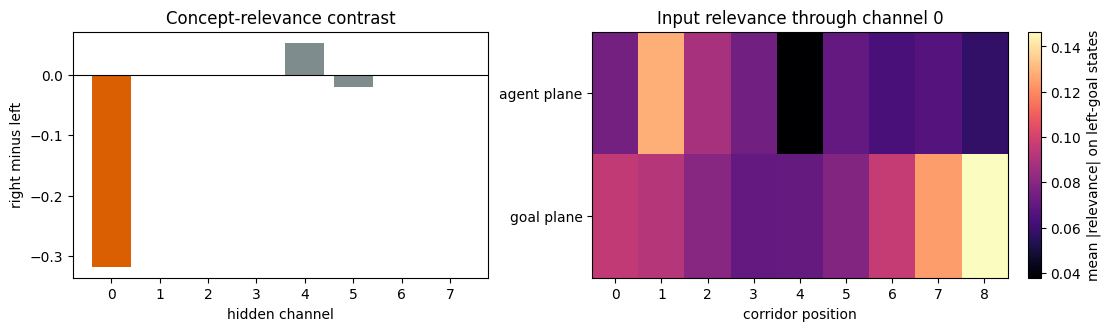

In [8]:
left_relevance = conditioned_relevance[goal_is_right == 0].abs().mean(0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
axes[0].bar(
    np.arange(FEATURES),
    selection_scores.cpu(),
    color=["#d95f02" if i == selected_channel else "#7f8c8d" for i in range(FEATURES)],
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Concept-relevance contrast", xlabel="hidden channel", ylabel="right minus left")

image = axes[1].imshow(left_relevance.cpu(), aspect="auto", cmap="magma")
axes[1].set(
    title=f"Input relevance through channel {selected_channel}",
    xlabel="corridor position",
    yticks=[0, 1],
    yticklabels=["agent plane", "goal plane"],
    xticks=np.arange(CORRIDOR_LENGTH),
)
fig.colorbar(image, ax=axes[1], label="mean |relevance| on left-goal states")
plt.show()

## 5. Turn the representational result into a causal test

First we capture the complete hidden representation using a serializable `Target`. We then replace the selected left-associated channel with its mean value in right-goal states.

This intervention is intentionally narrow:

- one layer;
- one of eight channels;
- no parameter update;
- the same replacement value for every evaluated state.

Matched interventions on all other channels serve as specificity controls.

In [9]:
feature_target = Target("features.2", "activation", -1, tuple(range(FEATURES)))
capture = Workflow(
    ActivationCaching(feature_target, cache_key=("activations", "candidate_layer")),
)
captured = capture(actor, evaluation_panel.select("observation").clone())
feature_values = captured["activations", "candidate_layer", "features.2"].detach()

right_context_means = feature_values[goal_is_right == 1].mean(0)
left_context_means = feature_values[goal_is_right == 0].mean(0)

print("Selected-channel means")
print(f"  left-goal states:  {left_context_means[selected_channel].item():.3f}")
print(f"  right-goal states: {right_context_means[selected_channel].item():.3f}")

Selected-channel means
  left-goal states:  0.539
  right-goal states: -0.367


In [10]:
selected_target = Target("features.2", "activation", -1, (selected_channel,))
replacement_value = float(right_context_means[selected_channel].item())


def replace_with_right_context(*, module_key: str, output: torch.Tensor) -> torch.Tensor:
    return torch.full_like(output, replacement_value)


intervention = Workflow(
    SteeringVectors([selected_target], steer_fn=replace_with_right_context),
)
intervention_plan = intervention.plan(actor, evaluation_panel.select("observation"))
print(f"Intervention plan: {intervention_plan.model_passes} model pass")
print("Serializable target:", selected_target.to_dict())

Intervention plan: 1 model pass
Serializable target: {'module_path': 'features.2', 'kind': 'activation', 'feature_axis': -1, 'indices': [0], 'parameter': None, 'output_path': []}


In [11]:
with torch.no_grad():
    baseline_values = actor(evaluation_panel.select("observation").clone())["action_value"].detach()
    intervened_values = intervention(actor, evaluation_panel.select("observation").clone())["action_value"].detach()

baseline_actions = baseline_values.argmax(-1)
intervened_actions = intervened_values.argmax(-1)
selected_flips = int((baseline_actions != intervened_actions).sum().item())
left_to_right = int(((baseline_actions == 0) & (intervened_actions == 1)).sum().item())

control_flips = []
for channel in range(FEATURES):
    control_target = Target("features.2", "activation", -1, (channel,))
    control_value = float(right_context_means[channel].item())

    def replace_control(*, module_key: str, output: torch.Tensor, value=control_value) -> torch.Tensor:
        return torch.full_like(output, value)

    control = Workflow(SteeringVectors([control_target], steer_fn=replace_control))
    with torch.no_grad():
        control_values = control(actor, evaluation_panel.select("observation").clone())["action_value"]
    control_flips.append(int((control_values.argmax(-1) != baseline_actions).sum().item()))

print(f"Selected-channel action flips: {selected_flips}/{len(observations)}")
print(f"Left-to-right flips: {left_to_right}")
print("Matched flips by channel:", control_flips)
assert selected_flips > max(flips for index, flips in enumerate(control_flips) if index != selected_channel)
assert left_to_right == selected_flips

Selected-channel action flips: 36/72
Left-to-right flips: 36
Matched flips by channel: [36, 0, 0, 0, 0, 0, 0, 0]


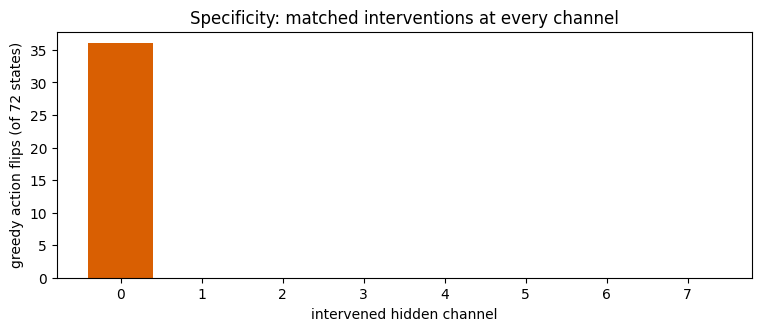

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.2), constrained_layout=True)
ax.bar(
    np.arange(FEATURES),
    control_flips,
    color=["#d95f02" if i == selected_channel else "#b0b7bc" for i in range(FEATURES)],
)
ax.set(
    title="Specificity: matched interventions at every channel",
    xlabel="intervened hidden channel",
    ylabel="greedy action flips (of 72 states)",
    xticks=np.arange(FEATURES),
)
plt.show()

## 6. Closed-loop validation

An action-logit change is not yet an RL result. We therefore keep the same intervention active while the policy interacts with the corridor.

The intervention disrupts the representative left-goal trajectory but preserves the matched right-goal trajectory. This establishes a behavioral consequence while also showing that the policy has not been indiscriminately disabled.

In [13]:
left_baseline, left_baseline_success = rollout(6, 1)
left_intervened, left_intervened_success = rollout(6, 1, intervention=intervention)
right_baseline, right_baseline_success = rollout(2, 7)
right_intervened, right_intervened_success = rollout(2, 7, intervention=intervention)

print("Left-goal baseline:   ", left_baseline, left_baseline_success)
print("Left-goal intervened: ", left_intervened, left_intervened_success)
print("Right-goal baseline:  ", right_baseline, right_baseline_success)
print("Right-goal intervened:", right_intervened, right_intervened_success)
assert left_baseline_success and not left_intervened_success
assert right_baseline_success and right_intervened_success

Left-goal baseline:    [6, 5, 4, 3, 2, 1] True
Left-goal intervened:  [6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8] False
Right-goal baseline:   [2, 3, 4, 5, 6, 7] True
Right-goal intervened: [2, 3, 4, 5, 6, 7] True


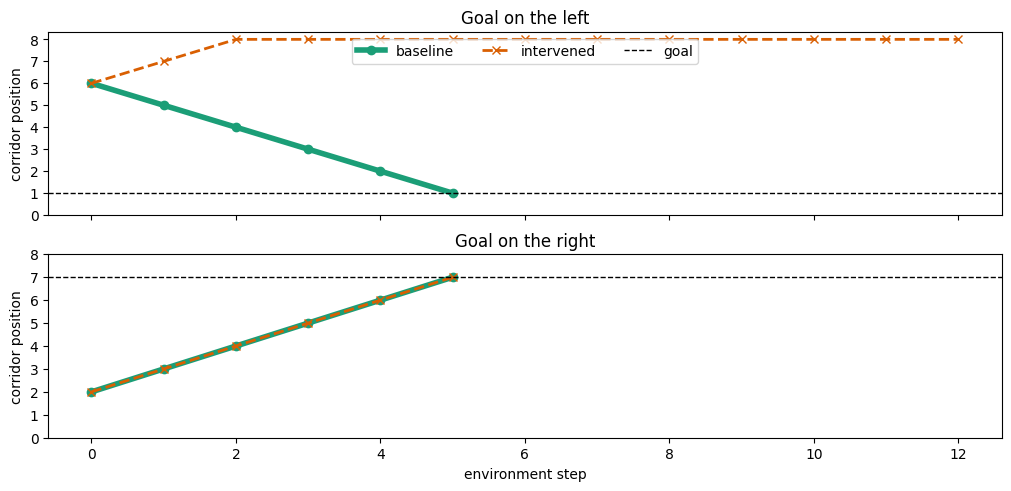

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True, constrained_layout=True)
for ax, title, goal, baseline_path, intervened_path in (
    (axes[0], "Goal on the left", 1, left_baseline, left_intervened),
    (axes[1], "Goal on the right", 7, right_baseline, right_intervened),
):
    ax.plot(
        range(len(baseline_path)),
        baseline_path,
        marker="o",
        linewidth=4,
        label="baseline",
        color="#1b9e77",
    )
    ax.plot(
        range(len(intervened_path)),
        intervened_path,
        marker="x",
        linestyle="--",
        linewidth=2,
        label="intervened",
        color="#d95f02",
    )
    ax.axhline(goal, color="black", linestyle="--", linewidth=1, label="goal")
    ax.set(title=title, ylabel="corridor position", yticks=np.arange(CORRIDOR_LENGTH))
axes[-1].set_xlabel("environment step")
axes[0].legend(ncol=3, loc="upper center")
plt.show()

## 7. What each stage established

| Evidence stage | Result | Claim boundary |
|---|---|---|
| Policy evaluation | 100% greedy accuracy and closed-loop success on the complete corridor panel | Competence only in this finite MDP |
| Concept-conditioned attribution | One hidden channel is selected for left-associated chosen-action relevance | Association, not causality |
| Conditioned input relevance | The selected channel can be traced to agent and goal input planes | Attribution under the configured LRP rules |
| Activation intervention | Replacing one selected channel flips left-going decisions; matched channel controls do not | Causal effect of this intervention on this policy |
| Paired rollouts | A left-goal trajectory fails while a right-goal trajectory remains successful | Closed-loop behavioral consequence, not a general theory of navigation |

The same investigation structure scales naturally to richer TorchRL data: replace corridor position with time-indexed observations, recurrent states, agent axes, actor/critic outputs, and paired rollout metrics. In MARL, the next question is not just whether a concept is encoded, but **which agent encodes it, when it appears, and whether intervening on that representation changes coordination without destroying competence**.

TDHook's contribution here is not a new attribution or intervention algorithm. It is the explicit, inspectable path from one method's artifact to the next scientific test.